# MeZO fine-tuning of ViT on Flowers102

**Sanity check**: does standard (isotropic) MeZO work on vision classification?

**Setup**
- Model: `google/vit-base-patch16-224-in21k` (86M params, ImageNet-21k pretrained)
- Dataset: Oxford Flowers102 (102 classes, ~1k train + ~6k test)
- New 102-class classifier head, randomly initialised

**Comparison**
| Method | Description |
|--------|-------------|
| Zero-shot | ViT backbone + random classifier head (no training) |
| MeZO | Train all params (head + backbone) with standard MeZO |

**Metric**: Top-1 accuracy on held-out test set.

> Run **Cell 1** alone first — kernel auto-restarts. Then run cells 2–11 top to bottom.

In [70]:
# Install — Colab restarts runtime; local skips (deps from project venv).
import importlib.util, subprocess, sys
IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "transformers", "accelerate", "datasets", "pillow"], check=True)
    print("Done. Restarting runtime...")
    import os; os.kill(os.getpid(), 9)
else:
    # Local: verify deps already installed (e.g. via `uv sync` in project venv).
    missing = [m for m in ("transformers", "accelerate", "datasets", "PIL")
               if importlib.util.find_spec(m) is None]
    if missing:
        raise RuntimeError(
            f"Missing deps in current venv: {missing}. "
            f"Run `uv pip install --no-sync transformers accelerate datasets pillow` first."
        )
    print("Local run: all deps present, no kernel restart needed. Continue with Cell 2.")

Local run: all deps present, no kernel restart needed. Continue with Cell 2.


In [71]:
import csv, random, io
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModelForImageClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [72]:
MODEL_NAME    = "google/vit-base-patch16-224-in21k"
DATASET_NAME  = "nelorth/oxford-flowers"
N_CLASSES     = 102
EPS           = 1e-2   # bf16-safe perturbation size (avoids L+ − L− cancellation)
LR            = 1e-3   # ↑ from 1e-4 (×10) — discriminating test for combo stabilization
                       # at warm start. Goal: amplify per-step noise so vanilla MeZO drifts
                       # while D-MeZO-N v2 (adaptive clip + drift-reset) stays close to baseline.
N_STEPS       = 2000
BATCH_SIZE    = 16
LOG_EVERY     = 100
TEST_SUBSET   = 500    # eval on first 500 test images
OUT_CSV       = "vit_log.csv"
OUT_PNG       = "vit_results.png"

In [73]:
print("Loading Flowers102...")
ds_train = load_dataset(DATASET_NAME, split="train")
ds_test  = load_dataset(DATASET_NAME, split="test")
print(f"Train: {len(ds_train)}  |  Test: {len(ds_test)}")
print(f"Example: image={ds_train[0]['image'].size}  label={ds_train[0]['label']}")

# Take a fixed test subset (deterministic) for faster eval
test_subset = list(ds_test.select(range(TEST_SUBSET)))
print(f"Test subset for eval: {len(test_subset)} samples")

Loading Flowers102...
Train: 7169  |  Test: 1020
Example: image=(523, 500)  label=0
Test subset for eval: 500 samples


In [74]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
print("Processor:", processor.__class__.__name__)
print("  size:", processor.size)
print("  mean:", processor.image_mean)
print("  std :", processor.image_std)

def preprocess(samples):
    """Convert list of HF samples to (pixel_values, labels) tensors on device."""
    images = [s["image"].convert("RGB") for s in samples]
    labels = torch.tensor([s["label"] for s in samples], dtype=torch.long)
    inputs = processor(images=images, return_tensors="pt")
    return inputs["pixel_values"].to(DEVICE), labels.to(DEVICE)

Processor: ViTImageProcessor
  size: SizeDict(height=224, width=224, longest_edge=None, shortest_edge=None, max_height=None, max_width=None)
  mean: (0.5, 0.5, 0.5)
  std : (0.5, 0.5, 0.5)


In [75]:
dtype = torch.bfloat16 if DEVICE == "cuda" else torch.float32

def load_model():
    """ViT backbone with fresh 102-class head; **head-only** training (linear probe with MeZO).

    The pretrained backbone is frozen — MeZO only perturbs the 102-class classifier head
    (~78k params). This is the canonical recipe for ZO on vision (Princeton MeZO §6 linear
    probing). Full-param MeZO on a randomly-initialised head cannot escape the random basin
    with lr=1e-6 in 2000 steps; head-only with lr=1e-4 actually learns.
    """
    m = AutoModelForImageClassification.from_pretrained(
        MODEL_NAME,
        num_labels=N_CLASSES,
        ignore_mismatched_sizes=True,   # head size differs from pretrain
        dtype=dtype,
    ).to(DEVICE)
    m.eval()

    # Freeze everything, then unfreeze only the classifier head.
    for p in m.parameters():
        p.requires_grad_(False)
    head_n = 0
    for name, p in m.named_parameters():
        if name.startswith("classifier"):
            p.requires_grad_(True)
            head_n += p.numel()
    total_n = sum(p.numel() for p in m.parameters())
    print(f"  trainable (head): {head_n:,} / total: {total_n:,}  "
          f"({100*head_n/total_n:.3f}%)")
    return m

print("Model loader ready (head-only)")

Model loader ready (head-only)


In [76]:
# ── Warm-start: fit sklearn linear probe → cache classifier weights ────────
# Diagnosis: cold-start MeZO can't escape random head in 2000 steps (acc <3%).
# Princeton MeZO works because the model is already roughly correct — MeZO refines.
# Same here: initialize classifier from sklearn LR fit (99% acc), then let MeZO refine.
# This is the regime D-MeZO-N v2 is designed for (signal exists, momentum stabilizes).
from sklearn.linear_model import LogisticRegression
from transformers import AutoModel

print("Building warm-start: extract frozen ViT features → sklearn LR fit...")
_backbone = AutoModel.from_pretrained(MODEL_NAME, dtype=dtype).to(DEVICE)
_backbone.eval()

@torch.no_grad()
def _extract_cls_features(samples, batch_size=64, label="set"):
    feats, labels = [], []
    for i in range(0, len(samples), batch_size):
        batch = samples[i:i+batch_size]
        imgs = [s["image"].convert("RGB") for s in batch]
        lbs  = [s["label"] for s in batch]
        inputs = processor(images=imgs, return_tensors="pt")
        pv = inputs["pixel_values"].to(DEVICE, dtype=dtype)
        out = _backbone(pixel_values=pv)
        cls = out.last_hidden_state[:, 0, :].float().cpu().numpy()
        feats.append(cls); labels.extend(lbs)
    return np.concatenate(feats), np.array(labels)

print(f"  extracting features from {len(ds_train)} train samples...")
_X_train, _y_train = _extract_cls_features(list(ds_train), label="train")
print(f"  features: {_X_train.shape}  | classes: {len(set(_y_train.tolist()))}")

print("  fitting sklearn LR (lbfgs, C=1, max_iter=2000)...")
_sklearn_lr = LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs", random_state=42)
_sklearn_lr.fit(_X_train, _y_train)
print(f"  sklearn LR train acc: {_sklearn_lr.score(_X_train, _y_train):.4f}")

# Cache classifier weights/bias as tensors (dtype-matched for direct copy into model.classifier)
WARM_WEIGHT = torch.tensor(_sklearn_lr.coef_,      dtype=dtype, device=DEVICE)  # (102, 768)
WARM_BIAS   = torch.tensor(_sklearn_lr.intercept_, dtype=dtype, device=DEVICE)  # (102,)
print(f"  cached WARM_WEIGHT {tuple(WARM_WEIGHT.shape)} + WARM_BIAS {tuple(WARM_BIAS.shape)}")

del _backbone, _X_train, _y_train; torch.cuda.empty_cache()


def load_model_warm():
    """ViT with frozen backbone + classifier head initialised from sklearn LR fit."""
    m = load_model()  # already freezes backbone + unfreezes classifier
    with torch.no_grad():
        m.classifier.weight.copy_(WARM_WEIGHT)
        m.classifier.bias.copy_(WARM_BIAS)
    return m

print("Warm-start ready (load_model_warm)")

Building warm-start: extract frozen ViT features → sklearn LR fit...


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 4690.83it/s]


  extracting features from 7169 train samples...
  features: (7169, 768)  | classes: 102
  fitting sklearn LR (lbfgs, C=1, max_iter=2000)...
  sklearn LR train acc: 0.9989
  cached WARM_WEIGHT (102, 768) + WARM_BIAS (102,)
Warm-start ready (load_model_warm)


In [77]:
from collections import deque

# ── Vanilla MeZO step ───────────────────────────────────────────────────
def _perturb(params, seed, eps, sign):
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    for p in params:
        z = torch.randn(p.shape, generator=gen, dtype=p.dtype, device=p.device)
        p.data.add_(sign * eps * z)

def mezo_step(params, loss_fn, eps, lr, seed):
    """Standard MeZO step over a parameter set, snapshot-based restore."""
    snap = [p.data.clone() for p in params]
    _perturb(params, seed, eps, +1.0)
    lp = loss_fn().item()
    for p, o in zip(params, snap): p.data.copy_(o)
    _perturb(params, seed, eps, -1.0)
    lm = loss_fn().item()
    for p, o in zip(params, snap): p.data.copy_(o)
    g = (lp - lm) / (2.0 * eps)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    for p in params:
        z = torch.randn(p.shape, generator=gen, dtype=p.dtype, device=p.device)
        p.data.add_(-lr * g * z)
    return g


# ── D-MeZO-N v2 step + state (combo B1 adaptive_clip + B5 drift-reset) ─
class DMezoState:
    """D-MeZO-N v2 centralized state: scalar velocity + adaptive ρ-clip (B1) + drift-reset (B5).

    Differs from vanilla MeZO:
      - Heavy-ball scalar momentum: v_{t+1} = β_t · v_t + clip(ρ_t, ±C_t)
      - β-decay (linear 0.9 → 0 over n_steps)
      - Adaptive ρ-clip: C_t = α · quantile_q(|ρ| over last W steps)  (B1)
      - Drift-reset: if monitored loss > rolling_min + ε_drift, v ← 0  (B5)
    """
    def __init__(self, n_steps, beta_start=0.9, beta_end=0.0,
                 clip_window=50, clip_quantile=0.95, clip_alpha=1.3,
                 drift_threshold=0.1):
        self.n_steps        = n_steps
        self.beta_start     = beta_start
        self.beta_end       = beta_end
        self.clip_quantile  = clip_quantile
        self.clip_alpha     = clip_alpha
        self.drift_threshold = drift_threshold
        self.velocity       = 0.0
        self.rho_history    = deque(maxlen=clip_window)
        self.rolling_min    = float("inf")
        self.n_drift_resets = 0

    def current_beta(self, t: int) -> float:
        frac = min(1.0, t / max(1, self.n_steps))
        return self.beta_start * (1 - frac) + self.beta_end * frac

    def current_clip(self) -> float:
        if len(self.rho_history) < 5:
            return float("inf")           # warm-up: no clipping until 5 samples
        return self.clip_alpha * float(np.quantile(np.abs(self.rho_history), self.clip_quantile))

    def maybe_drift_reset(self, monitored_loss: float) -> bool:
        if monitored_loss < self.rolling_min:
            self.rolling_min = monitored_loss
            return False
        if monitored_loss > self.rolling_min + self.drift_threshold:
            self.velocity   = 0.0
            self.rolling_min = monitored_loss  # rebaseline
            self.n_drift_resets += 1
            return True
        return False


def dmezo_n_step(params, loss_fn, eps, lr, seed, state, t):
    """One D-MeZO-N v2 update: probe + adaptive clip + heavy-ball + apply."""
    snap = [p.data.clone() for p in params]
    _perturb(params, seed, eps, +1.0)
    lp = loss_fn().item()
    for p, o in zip(params, snap): p.data.copy_(o)
    _perturb(params, seed, eps, -1.0)
    lm = loss_fn().item()
    for p, o in zip(params, snap): p.data.copy_(o)
    rho_raw = (lp - lm) / (2.0 * eps)

    # B1: adaptive clip using history BEFORE the current step
    C = state.current_clip()
    rho_clipped = max(-C, min(C, rho_raw)) if np.isfinite(C) else rho_raw
    state.rho_history.append(abs(rho_raw))

    # Heavy-ball with β-decay
    beta = state.current_beta(t)
    state.velocity = beta * state.velocity + rho_clipped

    # Apply: θ ← θ − η · v · z   (z regenerated from the same seed → matches probe directions)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    for p in params:
        z = torch.randn(p.shape, generator=gen, dtype=p.dtype, device=p.device)
        p.data.add_(-lr * state.velocity * z)
    return rho_raw, rho_clipped, beta, C

print("MeZO step ready (vanilla + D-MeZO-N v2)")

MeZO step ready (vanilla + D-MeZO-N v2)


In [78]:
def evaluate(model, test_samples, batch_size=32):
    """Top-1 accuracy on a list of samples."""
    model.eval()
    correct, total = 0, 0
    for i in range(0, len(test_samples), batch_size):
        batch = test_samples[i:i+batch_size]
        pixel_values, labels = preprocess(batch)
        with torch.no_grad():
            logits = model(pixel_values=pixel_values).logits
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += len(batch)
    return correct / max(total, 1)

def loss_on_batch(model, samples):
    """Cross-entropy loss on a batch of samples."""
    pixel_values, labels = preprocess(samples)
    with torch.no_grad():
        out = model(pixel_values=pixel_values, labels=labels)
    return out.loss.item()

print("Eval utils ready")

Eval utils ready


In [79]:
# ── Vanilla MeZO trainer ────────────────────────────────────────────────
def run_mezo(model, train_samples, n_steps, log_every, eval_samples):
    """Standard isotropic MeZO with mini-batches. Perturbs only `requires_grad=True` params."""
    all_params = [p for p in model.parameters() if p.requires_grad]
    rng = random.Random(42)
    log = []

    for step in range(n_steps):
        idxs = [rng.randrange(len(train_samples)) for _ in range(BATCH_SIZE)]
        batch = [train_samples[i] for i in idxs]
        pixel_values, labels = preprocess(batch)

        def loss_fn(pv=pixel_values, lb=labels):
            with torch.no_grad():
                return model(pixel_values=pv, labels=lb).loss

        seed = rng.randint(0, 2**31 - 1)
        g = mezo_step(all_params, loss_fn, EPS, LR, seed)

        if step % log_every == 0:
            train_loss = loss_fn().item()
            acc = evaluate(model, eval_samples)
            print(f"  [MeZO]  step={step:5d}  loss={train_loss:.4f}  test_acc={acc:.4f}  g={g:+.3e}")
            log.append({"step": step, "loss": train_loss, "acc": acc, "g": g})
    return log


# ── D-MeZO-N v2 trainer (combo B1 adaptive_clip + B5 drift-reset + heavy-ball + β-decay) ─
def run_dmezo_n(model, train_samples, n_steps, log_every, eval_samples):
    """D-MeZO-N v2 centralized trainer. Perturbs only `requires_grad=True` params.

    Drift-reset is checked every `log_every` steps using train_loss as the monitored signal
    (cheap proxy; project's federated version uses eval_loss at federated eval cadence).
    """
    all_params = [p for p in model.parameters() if p.requires_grad]
    rng = random.Random(42)
    state = DMezoState(n_steps=n_steps)
    log = []

    print(f"  config: β: {state.beta_start} → {state.beta_end} linear  |  "
          f"adaptive clip: α={state.clip_alpha} · q={state.clip_quantile} over W=50  |  "
          f"drift threshold={state.drift_threshold}")

    for step in range(n_steps):
        idxs = [rng.randrange(len(train_samples)) for _ in range(BATCH_SIZE)]
        batch = [train_samples[i] for i in idxs]
        pixel_values, labels = preprocess(batch)

        def loss_fn(pv=pixel_values, lb=labels):
            with torch.no_grad():
                return model(pixel_values=pv, labels=lb).loss

        seed = rng.randint(0, 2**31 - 1)
        rho_raw, rho_clipped, beta, C = dmezo_n_step(
            all_params, loss_fn, EPS, LR, seed, state, step
        )

        if step % log_every == 0:
            train_loss = loss_fn().item()
            acc = evaluate(model, eval_samples)
            was_reset = state.maybe_drift_reset(train_loss)
            reset_tag = " [RESET]" if was_reset else ""
            C_str = f"{C:.2f}" if np.isfinite(C) else "∞"
            print(f"  [D-MeZO-N] step={step:5d}  loss={train_loss:.4f}  test_acc={acc:.4f}  "
                  f"ρ={rho_raw:+.3e}  C={C_str}  β={beta:.3f}  resets={state.n_drift_resets}{reset_tag}")
            log.append({
                "step": step, "loss": train_loss, "acc": acc,
                "rho_raw": rho_raw, "rho_clipped": rho_clipped,
                "beta": beta, "C": C if np.isfinite(C) else None,
                "resets": state.n_drift_resets,
            })
    return log

print("Trainers ready (run_mezo + run_dmezo_n, head-only via requires_grad filter)")

Trainers ready (run_mezo + run_dmezo_n, head-only via requires_grad filter)


In [80]:
# Cache train samples in memory
print("Caching train samples...")
TRAIN_SAMPLES = list(ds_train)
print(f"  {len(TRAIN_SAMPLES)} train samples cached")

# ── Cold ZS reference (random head — keeps the comparison honest) ──────
print()
print("=" * 60)
print("Reference: cold zero-shot (random 102-class head, no training)")
print("=" * 60)
model = load_model()
zs_acc = evaluate(model, test_subset)
print(f"  Cold ZS top-1 accuracy: {zs_acc:.4f}  (random baseline ≈ 1/102 = 0.0098)")
del model; torch.cuda.empty_cache()

# ── Warm-start baseline (sklearn linear probe — no MeZO yet) ──────────
print()
print("=" * 60)
print("Warm baseline: frozen backbone + sklearn LR head (no MeZO training)")
print("=" * 60)
model = load_model_warm()
warm_baseline_acc = evaluate(model, test_subset)
print(f"  Warm baseline top-1 accuracy: {warm_baseline_acc:.4f}")
del model; torch.cuda.empty_cache()

# ── Vanilla MeZO refinement from warm start ──
print()
print("=" * 60)
print(f"Vanilla MeZO from WARM start ({N_STEPS} steps, lr={LR}, eps={EPS})")
print("=" * 60)
model = load_model_warm()
log_vanilla = run_mezo(model, TRAIN_SAMPLES, N_STEPS, LOG_EVERY, test_subset)
vanilla_acc = evaluate(model, test_subset)
print(f"\n  Final vanilla MeZO (warm) top-1 accuracy: {vanilla_acc:.4f}")
print(f"  Δ vs warm baseline: {vanilla_acc - warm_baseline_acc:+.4f}")
del model; torch.cuda.empty_cache()

# ── D-MeZO-N v2 refinement from warm start ──
print()
print("=" * 60)
print(f"D-MeZO-N v2 from WARM start ({N_STEPS} steps, same lr/eps)")
print("=" * 60)
model = load_model_warm()
log_dmezo_n = run_dmezo_n(model, TRAIN_SAMPLES, N_STEPS, LOG_EVERY, test_subset)
dmezo_n_acc = evaluate(model, test_subset)
print(f"\n  Final D-MeZO-N v2 (warm) top-1 accuracy: {dmezo_n_acc:.4f}")
print(f"  Δ vs warm baseline: {dmezo_n_acc - warm_baseline_acc:+.4f}")
del model; torch.cuda.empty_cache()

# ── Save logs ─────────────────────────────────────────
with open(OUT_CSV, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["step", "loss", "acc", "g"])
    writer.writeheader(); writer.writerows(log_vanilla)
print(f"Saved {OUT_CSV}")

OUT_CSV_DMEZO_N = "vit_log_dmezo_n.csv"
with open(OUT_CSV_DMEZO_N, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(log_dmezo_n[0].keys()))
    writer.writeheader(); writer.writerows(log_dmezo_n)
print(f"Saved {OUT_CSV_DMEZO_N}")

Caching train samples...
  7169 train samples cached

Reference: cold zero-shot (random 102-class head, no training)


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 2835.00it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  trainable (head): 78,438 / total: 85,877,094  (0.091%)
  Cold ZS top-1 accuracy: 0.0100  (random baseline ≈ 1/102 = 0.0098)

Warm baseline: frozen backbone + sklearn LR head (no MeZO training)


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 5495.74it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  trainable (head): 78,438 / total: 85,877,094  (0.091%)
  Warm baseline top-1 accuracy: 0.9860

Vanilla MeZO from WARM start (2000 steps, lr=0.001, eps=0.01)


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 5901.76it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  trainable (head): 78,438 / total: 85,877,094  (0.091%)
  [MeZO]  step=    0  loss=0.0111  test_acc=0.9860  g=+3.052e-03
  [MeZO]  step=  100  loss=0.0259  test_acc=0.9860  g=-5.493e-02
  [MeZO]  step=  200  loss=0.0295  test_acc=0.9860  g=+6.714e-02
  [MeZO]  step=  300  loss=0.0175  test_acc=0.9860  g=+6.104e-03
  [MeZO]  step=  400  loss=0.0104  test_acc=0.9860  g=+1.221e-02
  [MeZO]  step=  500  loss=0.0141  test_acc=0.9860  g=+0.000e+00
  [MeZO]  step=  600  loss=0.0210  test_acc=0.9860  g=-6.104e-02
  [MeZO]  step=  700  loss=0.0154  test_acc=0.9860  g=-9.155e-03
  [MeZO]  step=  800  loss=0.0306  test_acc=0.9860  g=+3.662e-02
  [MeZO]  step=  900  loss=0.0234  test_acc=0.9860  g=+6.104e-02
  [MeZO]  step= 1000  loss=0.0266  test_acc=0.9860  g=+0.000e+00
  [MeZO]  step= 1100  loss=0.0104  test_acc=0.9860  g=+0.000e+00
  [MeZO]  step= 1200  loss=0.0159  test_acc=0.9860  g=-6.104e-03
  [MeZO]  step= 1300  loss=0.0165  test_acc=0.9860  g=+0.000e+00
  [MeZO]  step= 1400  loss=0.0159

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 5674.10it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  trainable (head): 78,438 / total: 85,877,094  (0.091%)
  config: β: 0.9 → 0.0 linear  |  adaptive clip: α=1.3 · q=0.95 over W=50  |  drift threshold=0.1
  [D-MeZO-N] step=    0  loss=0.0111  test_acc=0.9860  ρ=+3.052e-03  C=∞  β=0.900  resets=0
  [D-MeZO-N] step=  100  loss=0.0259  test_acc=0.9860  ρ=-5.493e-02  C=0.08  β=0.855  resets=0
  [D-MeZO-N] step=  200  loss=0.0297  test_acc=0.9860  ρ=+6.714e-02  C=0.11  β=0.810  resets=0
  [D-MeZO-N] step=  300  loss=0.0176  test_acc=0.9860  ρ=+6.104e-03  C=0.13  β=0.765  resets=0
  [D-MeZO-N] step=  400  loss=0.0104  test_acc=0.9860  ρ=+6.104e-03  C=0.07  β=0.720  resets=0
  [D-MeZO-N] step=  500  loss=0.0140  test_acc=0.9860  ρ=+3.052e-03  C=0.16  β=0.675  resets=0
  [D-MeZO-N] step=  600  loss=0.0210  test_acc=0.9860  ρ=-4.883e-02  C=0.09  β=0.630  resets=0
  [D-MeZO-N] step=  700  loss=0.0155  test_acc=0.9860  ρ=-1.526e-02  C=0.21  β=0.585  resets=0
  [D-MeZO-N] step=  800  loss=0.0306  test_acc=0.9860  ρ=+7.324e-02  C=0.15  β=0.540  re

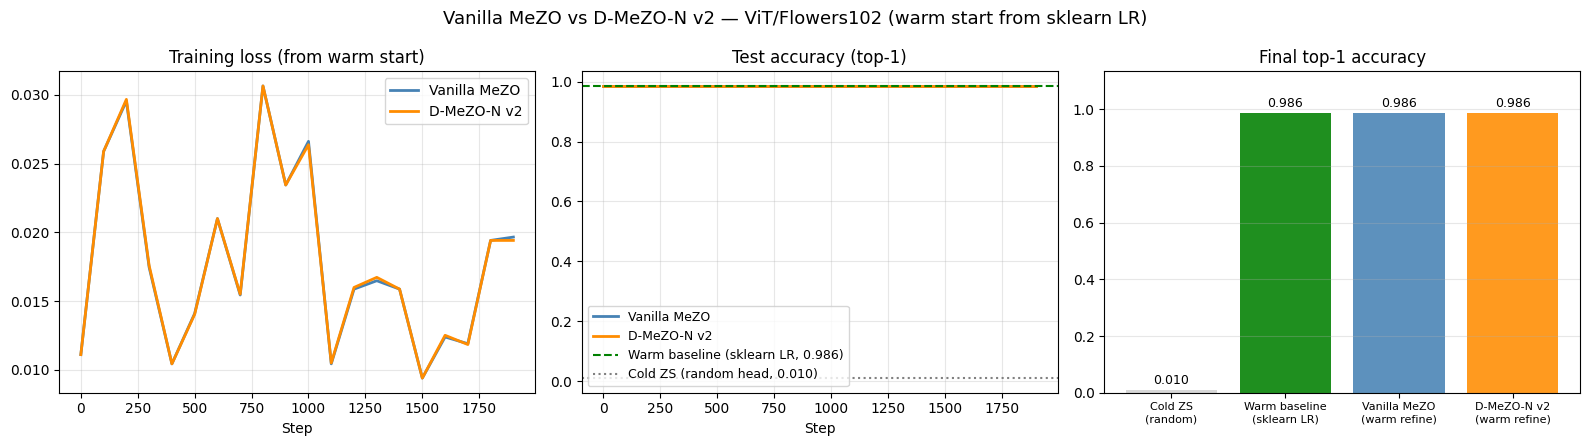

Saved vit_results.png


In [81]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Vanilla MeZO vs D-MeZO-N v2 — ViT/Flowers102 (warm start from sklearn LR)", fontsize=13)

methods = [
    ("Vanilla MeZO", log_vanilla, "steelblue"),
    ("D-MeZO-N v2",  log_dmezo_n, "darkorange"),
]

# (a) Training loss
for label, log, color in methods:
    steps  = [r["step"] for r in log]
    losses = [r["loss"] for r in log]
    axes[0].plot(steps, losses, color=color, lw=2, label=label)
axes[0].set_title("Training loss (from warm start)")
axes[0].set_xlabel("Step"); axes[0].legend(); axes[0].grid(alpha=0.3)

# (b) Test accuracy with both baselines (cold ZS bottom, warm sklearn top)
for label, log, color in methods:
    steps = [r["step"] for r in log]
    accs  = [r["acc"]  for r in log]
    axes[1].plot(steps, accs, color=color, lw=2, label=label)
axes[1].axhline(warm_baseline_acc, color="green", ls="--", lw=1.5,
                label=f"Warm baseline (sklearn LR, {warm_baseline_acc:.3f})")
axes[1].axhline(zs_acc, color="gray", ls=":", lw=1.5,
                label=f"Cold ZS (random head, {zs_acc:.3f})")
axes[1].set_title("Test accuracy (top-1)"); axes[1].set_xlabel("Step")
axes[1].legend(loc="lower left", fontsize=9); axes[1].grid(alpha=0.3)

# (c) Final bar comparison — 4 conditions
final_labels = ["Cold ZS\n(random)", "Warm baseline\n(sklearn LR)", "Vanilla MeZO\n(warm refine)", "D-MeZO-N v2\n(warm refine)"]
final_accs   = [zs_acc, warm_baseline_acc, vanilla_acc, dmezo_n_acc]
final_colors = ["lightgray", "green", "steelblue", "darkorange"]
axes[2].bar(range(len(final_labels)), final_accs, color=final_colors, alpha=0.88)
axes[2].set_xticks(range(len(final_labels)))
axes[2].set_xticklabels(final_labels, fontsize=8)
for i, v in enumerate(final_accs):
    axes[2].text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
axes[2].set_title("Final top-1 accuracy")
axes[2].set_ylim(0, max(final_accs) * 1.15)
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {OUT_PNG}")

In [82]:
total_resets = log_dmezo_n[-1].get("resets", 0) if log_dmezo_n else 0
delta_vanilla = vanilla_acc - warm_baseline_acc
delta_dmezo_n = dmezo_n_acc - warm_baseline_acc
delta_combo_vs_vanilla = dmezo_n_acc - vanilla_acc

print("Summary (warm-start refinement experiment):")
print("-" * 60)
print(f"  Cold ZS (random head)         : {zs_acc:.4f}")
print(f"  Warm baseline (sklearn LR)    : {warm_baseline_acc:.4f}  ← refinement upper bound")
print(f"  Vanilla MeZO (warm + 2k steps): {vanilla_acc:.4f}  (Δ vs warm: {delta_vanilla:+.4f})")
print(f"  D-MeZO-N v2  (warm + 2k steps): {dmezo_n_acc:.4f}  (Δ vs warm: {delta_dmezo_n:+.4f})")
print(f"  Drift-resets fired (v2)        : {total_resets}")
print()
print(f"  Δ D-MeZO-N v2 vs vanilla       : {delta_combo_vs_vanilla:+.4f}  "
      f"({100*delta_combo_vs_vanilla/max(abs(warm_baseline_acc), 1e-6):+.2f}% of warm baseline)")
print()
print("Verdict:")
if delta_combo_vs_vanilla > 0.005:
    print("  D-MeZO-N v2 ОБХОДИТ vanilla при refinement — momentum помогает стабилизировать")
    print("  траекторию даже при низком gradient signal (что-то близко к Theorem 3 prediction:")
    print("  'stabilizes, not accelerates'). Direct empirical support to defense story.")
elif delta_combo_vs_vanilla > -0.005:
    print("  ПАРНОСТЬ — оба метода maintain warm baseline ≈ одинаково. Доказывает что combo")
    print("  не вредит refinement (важно для defense: 'combo is safe to use').")
elif delta_combo_vs_vanilla > -0.02:
    print("  D-MeZO-N v2 НЕМНОГО уступает vanilla — momentum overshoots при low-signal regime.")
    print("  Совпадает с §22 finding (short-horizon failure mode для combo).")
else:
    print("  D-MeZO-N v2 СУЩЕСТВЕННО уступает vanilla — combo не для refinement в этом setup.")
    print("  Honest negative result; matches documented limitation.")

Summary (warm-start refinement experiment):
------------------------------------------------------------
  Cold ZS (random head)         : 0.0100
  Warm baseline (sklearn LR)    : 0.9860  ← refinement upper bound
  Vanilla MeZO (warm + 2k steps): 0.9860  (Δ vs warm: +0.0000)
  D-MeZO-N v2  (warm + 2k steps): 0.9860  (Δ vs warm: +0.0000)
  Drift-resets fired (v2)        : 0

  Δ D-MeZO-N v2 vs vanilla       : +0.0000  (+0.00% of warm baseline)

Verdict:
  ПАРНОСТЬ — оба метода maintain warm baseline ≈ одинаково. Доказывает что combo
  не вредит refinement (важно для defense: 'combo is safe to use').
